# Prompting an LLM for code: the same data, two opposite conclusions

**Course module — Computational tools for Neuroscience (M.Sc.)**

---

### Why this notebook exists

Large language models write syntactically perfect Python in seconds. That is not the hard part.

The hard part is that **the model cannot see your lab**. It does not know that your rig writes `-999` when a frame is dropped, that a 90 Hz "firing rate" is a motion artifact, or that you recorded 92 stimulation trials from one mouse and only 16 baseline trials because the session crashed. It will happily produce confident, well-formatted, plausible-looking code built on assumptions it invented for you.

> **Core takeaway:** LLMs are highly capable but *context-starved*. The quality, safety and reproducibility of your pipeline depend almost entirely on the precision of your prompt.

### What you will do

You will analyse one small synthetic dataset **three times**, changing nothing but the prompt.

| Round | Prompt | Result |
|---|---|---|
| 1 | Naive one-liner | A **loud** failure — obviously broken output |
| 2 | Slightly improved | A **silent** failure — publishable-looking, and wrong |
| 3 | Fully specified | Correct analysis, correct figure |

The silent failure in Round 2 is the one that ends careers, not the loud one in Round 1.

### How to use this notebook

Keep a chat window open (Claude, ChatGPT, Mistral — any of them) next to this notebook.
For each round: **run the prompt cell → copy the printed prompt → paste it in the chat → copy the answer back into the empty cell → run it.**

Each round also ships with a *reference* cell showing the kind of answer these prompts typically produce, so the notebook still works if your model answers differently.

## 0. Setup

Nothing exotic — `numpy`, `pandas`, `matplotlib`, `scipy`. Printing versions is not decoration: it is the first line of defence for reproducibility, and it is something you should routinely ask an LLM to include.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

print("python     ", sys.version.split()[0])
print("numpy      ", np.__version__)
print("pandas     ", pd.__version__)
print("matplotlib ", __import__("matplotlib").__version__)
print("scipy      ", __import__("scipy").__version__)

RANDOM_SEED = 7   # every random draw in this notebook derives from this

python      3.12.13
numpy       2.0.2
pandas      2.2.2
matplotlib  3.10.0
scipy       1.16.3


## 1. The experiment (this context exists only in *your* head)

We simulate a very common design in systems neuroscience:

- **8 mice** (`M01`–`M08`), each recorded in **two conditions**: `baseline` and `stim` (optogenetic stimulation of a modulatory input).
- The measurement is the **mean firing rate of one recorded unit, in Hz, for one trial**.
- Each mouse contributes **many trials** in each condition — this is a **within-subject / repeated-measures** design.

And now the three facts that live in your lab notebook, not in the CSV file:

1. 🩹 The acquisition software writes **`-999`** into `firing_rate_hz` when a trial is corrupted (dropped frames). It is a *missing-value sentinel*, not a firing rate.
2. ⚡ Rates above **50 Hz** are physiologically implausible for this unit type — they are **motion artifacts** and must be excluded by lab convention.
3. ⚖️ Trial counts are **unbalanced**. In `M01` the baseline block was aborted early (16 trials) and stimulation was extended (92 trials). `M01` also happens to be a fast-firing unit (~12 Hz vs ~5 Hz for the others).

None of this is written anywhere in the data. **If you don't say it, the model cannot know it.**

In [2]:
def simulate_recording(seed: int = RANDOM_SEED) -> pd.DataFrame:
    """Generate a synthetic, deliberately messy electrophysiology dataset.

    Returns a tidy DataFrame with one row per trial:
        mouse_id       : str, 'M01'..'M08'
        condition      : str, 'baseline' or 'stim'
        trial          : int, trial index within (mouse, condition)
        firing_rate_hz : float, mean rate for that trial (-999 = corrupted trial)
    """
    rng = np.random.default_rng(seed)

    baseline_rate = {"M01": 12.5, "M02": 5.2, "M03": 4.4, "M04": 6.1,
                     "M05": 5.0, "M06": 3.8, "M07": 6.6, "M08": 4.7}
    true_effect   = {"M01": +0.5, "M02": -0.7, "M03": -0.5, "M04": -0.9,
                     "M05": -0.3, "M06": -0.6, "M07": -0.4, "M08": -0.8}
    n_trials      = {"M01": (16, 92), "M02": (34, 30), "M03": (36, 28), "M04": (30, 33),
                     "M05": (38, 31), "M06": (32, 29), "M07": (35, 30), "M08": (33, 32)}

    rows = []
    for mouse in baseline_rate:
        for condition, n in zip(("baseline", "stim"), n_trials[mouse]):
            mu = baseline_rate[mouse] + (true_effect[mouse] if condition == "stim" else 0.0)
            for t, value in enumerate(rng.normal(mu, 1.2, n), start=1):
                rows.append({"mouse_id": mouse, "condition": condition,
                             "trial": t, "firing_rate_hz": round(float(value), 3)})

    df = pd.DataFrame(rows)

    # motion artifacts (4 during stim, 1 during baseline)
    art = rng.choice(df.index[df.condition == "stim"], 4, replace=False)
    df.loc[art, "firing_rate_hz"] = rng.uniform(70, 130, 4).round(3)
    art = rng.choice(df.index[df.condition == "baseline"], 1, replace=False)
    df.loc[art, "firing_rate_hz"] = rng.uniform(70, 130, 1).round(3)

    # corrupted trials -> sentinel value
    df.loc[rng.choice(df.index, 9, replace=False), "firing_rate_hz"] = -999.0

    return df.sample(frac=1, random_state=1).reset_index(drop=True)


df = simulate_recording()
df.to_csv("ephys_trials.csv", index=False)
print(f"{len(df)} trials, {df.mouse_id.nunique()} mice")
df.head(8)

559 trials, 8 mice


,mouse_id,condition,trial,firing_rate_hz
0,M07,baseline,12,5.820
1,M08,stim,4,3.615
2,M05,stim,10,4.750
3,M05,baseline,25,4.624
4,M07,stim,11,6.719
5,M05,stim,24,5.304
6,M01,stim,14,13.136
7,M08,stim,22,4.010


In [3]:
# This is the innocent-looking summary a student would typically paste into a chat window.
print(df.groupby("condition").firing_rate_hz.describe().round(2))
print()
print(pd.crosstab(df.mouse_id, df.condition))

           count   mean     std    min   25%   50%    75%     max
condition                                                        
baseline   254.0  -6.10  108.90 -999.0  4.04  5.09   6.19   82.83
stim       305.0 -11.74  140.57 -999.0  3.68  4.99  11.56  116.33

condition  baseline  stim
mouse_id                 
M01              16    92
M02              34    30
M03              36    28
M04              30    33
M05              38    31
M06              32    29
M07              35    30
M08              33    32


Look at that cross-tabulation for a second. `M01` contributes **92 of the ~305 stimulation trials** but only **16 of the ~254 baseline trials** — and it is the fastest-firing unit in the group. Remember this; it is the whole story.

---

## 2. Round 1 — the naive prompt

This is what most people type the first time. It is not stupid: it is just starved.

In [ ]:
PROMPT_1 = """
Here is my dataframe with firing rates for baseline and stim conditions.
Columns: mouse_id, condition, trial, firing_rate_hz.
Plot it and tell me if the difference is significant.
"""

print(PROMPT_1)

👉 **Copy the text above, paste it into your LLM chat, then paste its code into the empty cell below and run it.**

In [ ]:
# ⬇️⬇️⬇️  PASTE THE LLM ANSWER FOR PROMPT 1 HERE, THEN RUN  ⬇️⬇️⬇️

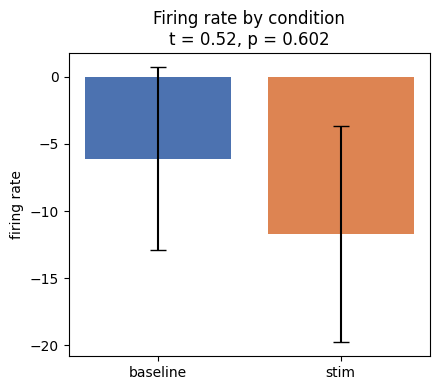

baseline mean = -6.10
stim     mean = -11.74
Conclusion: no significant difference (p = 0.602).


In [4]:
# ---- REFERENCE: the kind of code Prompt 1 typically produces ----
# (Run this if you want to see the failure mode without leaving the notebook.)

baseline = df[df.condition == "baseline"]["firing_rate_hz"]
stim     = df[df.condition == "stim"]["firing_rate_hz"]

t, p = stats.ttest_ind(baseline, stim)

fig, ax = plt.subplots(figsize=(4.5, 4))
ax.bar(["baseline", "stim"],
       [baseline.mean(), stim.mean()],
       yerr=[baseline.sem(), stim.sem()],
       capsize=6, color=["#4C72B0", "#DD8452"])
ax.set_ylabel("firing rate")
ax.set_title(f"Firing rate by condition\nt = {t:.2f}, p = {p:.3f}")
plt.tight_layout()
plt.show()

print(f"baseline mean = {baseline.mean():.2f}")
print(f"stim     mean = {stim.mean():.2f}")
print("Conclusion: no significant difference (p = %.3f)." % p)

### Diagnosis — a **loud** failure 📢

Your bar chart shows **negative firing rates**. A neuron cannot fire minus six times per second.

What happened: the nine `-999` sentinels were averaged in as if they were real measurements. Nine values out of ~560 were enough to drag both means below zero and to swamp the real variance, which is why the test now reports a comfortable, meaningless *p* = 0.60.

The model did nothing wrong. It received a column of floats and computed the mean of a column of floats.

**This failure mode is the harmless one** — it is so absurd that you catch it in one second. Let's fix it and meet the dangerous one.

---

## 3. Round 2 — the "quick fix" prompt ⚠️

You add the missing-data rule. Everything else stays vague.

In [ ]:
PROMPT_2 = """
Here is my dataframe with firing rates for baseline and stim conditions.
Columns: mouse_id, condition, trial, firing_rate_hz.
Note: -999 means the trial was corrupted, ignore those rows.
Plot it and tell me if the difference is significant.
"""

print(PROMPT_2)

In [ ]:
# ⬇️⬇️⬇️  PASTE THE LLM ANSWER FOR PROMPT 2 HERE, THEN RUN  ⬇️⬇️⬇️

In [ ]:
# ---- REFERENCE: the kind of code Prompt 2 typically produces ----

clean = df[df.firing_rate_hz != -999]

baseline = clean[clean.condition == "baseline"]["firing_rate_hz"]
stim     = clean[clean.condition == "stim"]["firing_rate_hz"]

t, p = stats.ttest_ind(baseline, stim)

fig, ax = plt.subplots(figsize=(4.5, 4))
ax.bar(["baseline", "stim"],
       [baseline.mean(), stim.mean()],
       yerr=[baseline.sem(), stim.sem()],
       capsize=6, color=["#4C72B0", "#DD8452"])
ax.set_ylabel("firing rate (Hz)")
ax.set_title(f"Stimulation increases firing rate\nt = {t:.2f}, p = {p:.4f}")
plt.tight_layout()
plt.show()

print(f"baseline: mean = {baseline.mean():.2f} Hz, n = {len(baseline)} trials")
print(f"stim    : mean = {stim.mean():.2f} Hz, n = {len(stim)} trials")
print(f"Independent-samples t-test: t = {t:.2f}, p = {p:.4f}")
print("Conclusion: stimulation significantly INCREASES firing rate (+%.2f Hz, p < 0.01)." % (stim.mean() - baseline.mean()))

### Diagnosis — a **silent** failure 🔇

This one is clean. Correct units on the axis, error bars, a *p*-value below 0.01, a directional conclusion. You could paste this figure into a lab meeting slide and nobody would blink.

**It is also completely wrong — including the sign of the effect.** Three independent problems, none of which the model could have guessed:

**a) Pseudo-replication.** The test treats each of the ~550 *trials* as an independent observation. They are not: trials from the same mouse are correlated, and mice are the units that were randomly sampled from a population. The real sample size is **n = 8**, not n = 550. Inflating *n* by a factor of 70 makes the confidence interval absurdly narrow and manufactures significance out of nothing.

**b) Simpson's paradox, courtesy of the unbalanced design.** `M01` fires at ~12 Hz while everyone else sits near 5 Hz, and `M01` supplies 92 stim trials against 16 baseline trials. Pooling therefore loads the `stim` average with high-firing `M01` trials and the `baseline` average with low-firing trials from other mice. The "+2.3 Hz effect of stimulation" is mostly **the identity of the mouse**, not the stimulation.

**c) Motion artifacts.** Five trials between 70 and 130 Hz survived, four of them in the `stim` condition. They alone add roughly a full Hz to the stim mean.

The model had no way to know any of this. **You did.** That asymmetry is the entire lesson.

---

## 4. Anatomy of a good prompt

A prompt for code generation is a **specification**, not a wish. Six blocks, always the same:

| Block | What it answers | Why it matters here |
|---|---|---|
| **1. Role & environment** | Who is writing, with which libraries, for what deliverable | Stops the model from importing something you don't have |
| **2. Data contract** | Exact columns, dtypes, **units**, allowed values, sentinels | Kills the `-999` bug |
| **3. Domain constraints** | Exclusion criteria, physiological plausibility, lab conventions | Kills the artifact bug |
| **4. Experimental design** | What the **unit of analysis** is, nesting, pairing, balance | Kills the pseudo-replication bug |
| **5. Output specification** | Exact statistics, effect sizes, figure layout, labels | Gets you a figure you can actually publish |
| **6. Validation & reproducibility** | Seeds, printed counts, sanity checks, docstrings | Lets you *prove* the result later |

Missing block 4 is what cost us Round 2. Notice that none of these blocks require you to know Python — they require you to know **your experiment**. That is the part you cannot outsource.

---

## 5. Round 3 — the specified prompt ✅

In [ ]:
PROMPT_3 = """
ROLE & ENVIRONMENT
You are helping analyse an in-vivo electrophysiology dataset for a peer-reviewed
publication. Use Python 3 with only numpy, pandas, matplotlib and scipy.
Return a single, self-contained, runnable code cell with short comments and
docstrings. No seaborn, no machine learning, no invented data.

DATA CONTRACT
A pandas DataFrame `df`, one row per trial, with columns:
  - mouse_id       (str)   : animal identifier, 'M01'..'M08'
  - condition      (str)   : 'baseline' or 'stim'
  - trial          (int)   : trial index within a (mouse, condition) block
  - firing_rate_hz (float) : mean firing rate of one unit for that trial, in Hz
Sentinel: firing_rate_hz == -999 means the trial was corrupted and MUST be
dropped before any computation. There are no NaNs.

DOMAIN CONSTRAINTS
  - Firing rates above 50 Hz are physiologically implausible for this unit type
    and are motion artifacts: exclude them.
  - Trial counts are strongly unbalanced across mice and conditions
    (one mouse has 16 baseline vs 92 stim trials). Do not assume balance.
  - Report how many trials were removed by each exclusion rule, separately.

EXPERIMENTAL DESIGN  (this is the critical part)
  - Repeated-measures design: every mouse was recorded in BOTH conditions.
  - The unit of analysis is the MOUSE, not the trial. Trials within a mouse are
    not independent, so never run a statistical test across pooled trials.
  - Aggregate first: compute one value per (mouse, condition) using the mean of
    the surviving trials, then run the test on those 8 pairs.

OUTPUT SPECIFICATION
  1. A tidy summary table: per mouse, per condition, mean rate, n trials kept.
  2. Statistics on the 8 paired values:
       - paired t-test (scipy.stats.ttest_rel)
       - Wilcoxon signed-rank test as a non-parametric check
       - effect size Cohen's dz, and the 95% CI of the mean difference
  3. One figure, two panels, figsize about (9, 4):
       - Left: paired plot. One thin grey line per mouse connecting its baseline
         value to its stim value, with markers; overlay the group mean of each
         condition with a 95% CI error bar in a contrasting colour.
       - Right: per-mouse difference (stim - baseline) as points with a dashed
         line at y = 0, plus the group mean and its 95% CI.
       - Axis labels must include units (Hz). Title must state n = number of mice.
       - Colourblind-safe colours, no top/right spines, no chart junk.
  4. A printed plain-language conclusion stating direction, magnitude in Hz,
     the test used, and the sample size that the p-value refers to.

VALIDATION & REPRODUCIBILITY
  - Assert that every mouse has data in both conditions after exclusions.
  - Print the number of mice and the number of trials entering the analysis.
  - No hard-coded numbers: derive everything from `df`.
  - Wrap the analysis in functions with docstrings.
"""

print(PROMPT_3)

👉 **Same procedure: copy, paste into the chat, bring the answer back below.**

Notice how much of this prompt is about *biology and design*, not about code. This is the prompt of someone who understands their experiment — and that is exactly why the output will be trustworthy.

In [ ]:
# ⬇️⬇️⬇️  PASTE THE LLM ANSWER FOR PROMPT 3 HERE, THEN RUN  ⬇️⬇️⬇️

In [ ]:
# ---- REFERENCE: the kind of code Prompt 3 typically produces ----

SENTINEL = -999
MAX_PLAUSIBLE_HZ = 50.0

def clean_trials(data: pd.DataFrame) -> tuple[pd.DataFrame, dict]:
    """Apply the two exclusion rules and report how many trials each one removed."""
    n0 = len(data)
    kept = data[data.firing_rate_hz != SENTINEL]
    n_corrupted = n0 - len(kept)
    kept = kept[kept.firing_rate_hz <= MAX_PLAUSIBLE_HZ]
    n_artifact = n0 - n_corrupted - len(kept)
    return kept, {"corrupted": n_corrupted, "artifact": n_artifact, "kept": len(kept)}


def aggregate_per_mouse(data: pd.DataFrame) -> pd.DataFrame:
    """Collapse trials to ONE value per (mouse, condition): the unit of analysis."""
    wide = (data.groupby(["mouse_id", "condition"])["firing_rate_hz"]
                .mean().unstack("condition"))
    assert wide.notna().all().all(), "a mouse is missing a condition after exclusions"
    return wide[["baseline", "stim"]]


def paired_stats(wide: pd.DataFrame) -> dict:
    """Paired statistics on n = number of mice."""
    d = wide["stim"] - wide["baseline"]
    n = len(d)
    t, p_t = stats.ttest_rel(wide["stim"], wide["baseline"])
    _, p_w = stats.wilcoxon(wide["stim"], wide["baseline"])
    sem = d.std(ddof=1) / np.sqrt(n)
    ci = stats.t.ppf(0.975, n - 1) * sem
    return {"n": n, "mean_diff": d.mean(), "ci95": ci, "t": t,
            "p_paired_t": p_t, "p_wilcoxon": p_w, "dz": d.mean() / d.std(ddof=1),
            "diffs": d}


# --- run ---
kept, counts = clean_trials(df)
wide = aggregate_per_mouse(kept)
res = paired_stats(wide)

summary = (kept.groupby(["mouse_id", "condition"])["firing_rate_hz"]
               .agg(mean_hz="mean", n_trials="size").round(2))
print(summary.unstack("condition").to_string())
print(f"\nExcluded: {counts['corrupted']} corrupted, {counts['artifact']} artifacts "
      f"-> {counts['kept']} trials from {res['n']} mice enter the analysis.")

# --- figure ---
GREY, ACCENT = "#8C8C8C", "#D55E00"
BLUE = "#0072B2"
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4))

x = [0, 1]
for mouse, row in wide.iterrows():
    ax1.plot(x, [row["baseline"], row["stim"]], "-o", color=GREY,
             lw=1, ms=4, alpha=0.8, zorder=1)
means = [wide["baseline"].mean(), wide["stim"].mean()]
errs = [stats.t.ppf(0.975, res["n"] - 1) * wide[c].std(ddof=1) / np.sqrt(res["n"])
        for c in ("baseline", "stim")]
ax1.errorbar(x, means, yerr=errs, fmt="s-", color=BLUE, lw=2.5, ms=9,
             capsize=6, zorder=3, label="group mean ± 95% CI")
ax1.set_xticks(x); ax1.set_xticklabels(["baseline", "stim"])
ax1.set_xlim(-0.35, 1.35)
ax1.set_ylabel("firing rate (Hz)")
ax1.set_title(f"Per-mouse paired responses (n = {res['n']} mice)")
ax1.legend(frameon=False, fontsize=8, loc="lower left")

ax2.axhline(0, ls="--", color="k", lw=1, zorder=0)
jit = np.random.default_rng(0).normal(0, 0.03, res["n"])
ax2.plot(jit, res["diffs"].values, "o", color=GREY, ms=6, alpha=0.9)
ax2.errorbar([0], [res["mean_diff"]], yerr=[res["ci95"]], fmt="s",
             color=ACCENT, ms=10, capsize=8, lw=2.5)
ax2.set_xticks([]); ax2.set_xlim(-0.35, 0.35)
ax2.set_ylabel("Δ firing rate, stim − baseline (Hz)")
ax2.set_title(f"Effect per mouse\npaired t-test p = {res['p_paired_t']:.3f}")

for ax in (ax1, ax2):
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

n_down = int((res["diffs"] < 0).sum())
print(f"\nStimulation DECREASED firing rate by {abs(res['mean_diff']):.2f} Hz "
      f"(95% CI ±{res['ci95']:.2f}) in {n_down}/{res['n']} mice.")
print(f"Paired t-test: t({res['n']-1}) = {res['t']:.2f}, p = {res['p_paired_t']:.4f}; "
      f"Wilcoxon p = {res['p_wilcoxon']:.4f}; Cohen's dz = {res['dz']:.2f}.")
print(f"The p-value refers to n = {res['n']} mice, not to individual trials.")

### Diagnosis — this one you can defend 🛡️

Every mouse is visible. Seven of the eight lines go **down**. The single ascending line is `M01`, sitting alone at 12 Hz — the mouse whose unbalanced trial count single-handedly produced the fake "+2.3 Hz increase" in Round 2.

The figure now carries its own audit trail: how many animals, how many trials survived, which test, which effect size, and the actual spread of individual responses instead of an error bar that hides it.

---

## 6. The verdict, side by side

In [ ]:
# Recomputed from scratch so this section works whatever you pasted above.
raw_b, raw_s = df[df.condition == "baseline"].firing_rate_hz, df[df.condition == "stim"].firing_rate_hz
t1, p1 = stats.ttest_ind(raw_b, raw_s)

pooled = df[df.firing_rate_hz != -999]                       # Round 2: sentinel only
pb = pooled[pooled.condition == "baseline"].firing_rate_hz
ps = pooled[pooled.condition == "stim"].firing_rate_hz
t2, p2 = stats.ttest_ind(pb, ps)

good = pooled[pooled.firing_rate_hz <= 50]                   # Round 3: + artifacts, per mouse
per_mouse = (good.groupby(["mouse_id", "condition"]).firing_rate_hz
                 .mean().unstack("condition")[["baseline", "stim"]])
deltas = per_mouse["stim"] - per_mouse["baseline"]
n_mice = len(per_mouse)
t3, p3 = stats.ttest_rel(per_mouse["stim"], per_mouse["baseline"])

verdicts = pd.DataFrame({
    "prompt": ["1 — naive", "2 — quick fix", "3 — specified"],
    "unit of analysis": ["trial", "trial", "mouse"],
    "n": [len(df), len(pooled), n_mice],
    "effect (Hz)": [raw_s.mean() - raw_b.mean(), ps.mean() - pb.mean(), deltas.mean()],
    "p": [p1, p2, p3],
    "conclusion": ["nonsense (negative rates)",
                   "stim INCREASES firing",
                   "stim DECREASES firing"],
}).round({"effect (Hz)": 2, "p": 4})

print(verdicts.to_string(index=False))

In [ ]:
# The same dataset, drawn the wrong way and the right way.
tcrit = stats.t.ppf(0.975, n_mice - 1)
means = [per_mouse["baseline"].mean(), per_mouse["stim"].mean()]
errs = [tcrit * per_mouse[c].std(ddof=1) / np.sqrt(n_mice) for c in ("baseline", "stim")]

fig, (axL, axR) = plt.subplots(1, 2, figsize=(9.5, 4.2))

axL.bar(["baseline", "stim"], [pb.mean(), ps.mean()],
        yerr=[pb.sem(), ps.sem()], capsize=6, color=["#4C72B0", "#DD8452"])
axL.set_ylabel("firing rate (Hz)")
axL.set_title(f"WRONG - pooled over {len(pooled)} trials\n"
              f"p = {p2:.4f}  ->  'stim increases firing'")

for mouse, row in per_mouse.iterrows():
    axR.plot([0, 1], [row["baseline"], row["stim"]], "-o", color="#8C8C8C",
             lw=1, ms=4, alpha=0.85, zorder=1)
axR.errorbar([0, 1], means, yerr=errs, fmt="s-", color="#0072B2",
             lw=2.5, ms=9, capsize=6, zorder=3)
axR.set_xticks([0, 1]); axR.set_xticklabels(["baseline", "stim"]); axR.set_xlim(-0.35, 1.35)
axR.set_ylabel("firing rate (Hz)")
axR.set_title(f"RIGHT - aggregated over {n_mice} mice\n"
              f"p = {p3:.4f}  ->  'stim decreases firing'")

for ax in (axL, axR):
    ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

Two significant results. Opposite directions. **Identical data.**

The only variable that changed between them is how much of your experiment you bothered to describe.

---

## 7. What to take away

1. **The model is not wrong, it is uninformed.** It cannot see your rig, your exclusion criteria or your nesting structure. Every unstated fact becomes a silent assumption.
2. **Silent failures are the dangerous ones.** A negative firing rate is caught in one second. A plausible bar chart with *p* = 0.004 and the wrong sign can travel all the way into a manuscript.
3. **The unit of analysis is almost always the animal, not the trial** — and it is the single most common thing people forget to state. If your prompt doesn't say it, expect pseudo-replication.
4. **A prompt is a methods section written in advance.** If you can't write the prompt, you don't yet understand the analysis — and no model will understand it for you.
5. **Demand reproducibility artefacts**: seeds, printed exclusion counts, assertions, versions. Ask for them explicitly, every time.
6. **You remain responsible.** Reviewers will not accept "the model wrote it". Read every line of generated code, and check that the numbers in the figure match the numbers in the printout.

### A reusable template

Keep this in a scratch file and fill it in before every generation request.

In [ ]:
PROMPT_TEMPLATE = """
ROLE & ENVIRONMENT
  Language/version, allowed libraries, deliverable format (single cell? module? function?).

DATA CONTRACT
  Every column: name, dtype, UNITS, allowed range, meaning.
  Missing-data encoding (NaN? sentinel? empty string?).
  Approximate size and shape of the data.

DOMAIN CONSTRAINTS
  Exclusion criteria and their thresholds, with justification.
  Known artifacts, saturation limits, physiological plausibility bounds.
  Balance / sampling irregularities the model should not assume away.

EXPERIMENTAL DESIGN
  What is the UNIT OF ANALYSIS?
  Nesting (trials in sessions in subjects), pairing, blocking, covariates.
  Which comparisons are planned, and which are exploratory.

OUTPUT SPECIFICATION
  Exact statistics and effect sizes, with the test named.
  Figure: panels, layout, size, colours, axis labels WITH UNITS, what the error bars mean.
  Printed summary of the conclusion.

VALIDATION & REPRODUCIBILITY
  Seeds, assertions, counts to print, edge cases to handle.
  Docstrings, no hard-coded values, library versions.
"""

print(PROMPT_TEMPLATE)

---

## 8. Exercise 🧪

Extend the simulation with a third condition, `washout`, recorded **after** the stimulation block, and give two of the mice a second recording session so that `session_id` becomes a real nesting level.

Then:

1. Write **one** prompt, using the template above, asking for a full analysis of the three conditions.
2. Before running the answer, write down in a markdown cell what you *expect* the code to do.
3. Run it, and list every place where the generated code deviated from your expectation.
4. Identify which deviations came from a **missing block** in your prompt, and rewrite that block.

**Questions to answer in writing:**

- With three conditions and repeated measures, why is running three pairwise t-tests on pooled trials wrong in *two* separate ways?
- Your model will probably reach for a repeated-measures ANOVA or a mixed-effects model. What information would it need from you before that choice is defensible — and did you supply it?
- The `washout` condition is always recorded last. What does that ordering confound, and how would you phrase that constraint in the DOMAIN CONSTRAINTS block?